# TODO:
 - add an option to see general trends? so how likely is the hottest day in a given month over time
 - how many days over said temp per year
 - maybe temp of 5% percentile over time?
    - why 5%? also them to choose? isnt that p hacking?
 - choose temp and see percentile over time

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap


from get_temperature_history import get_temperature_history

In [2]:
def get_place_temp_data(place_name, date, start_year=1980, days_range=7):
    PLACES = {'yodfat': (32.8366, 35.2715), 
              'tlv': (32.0853, 34.7818),
              'vlc': (39.4738, -0.3756),
              'nowhere': (41.79, -0.16),
              'vitoria': (42.849998, -2.683333),
              'paris': (48.8575, 2.3514),
              'berlin': (52.5200, 13.4050)}
    place = PLACES[place_name]
    data = get_temperature_history(place[0], place[1], date, start_year, days_range)
    return data

date = "2025-08-13"
city = 'tlv'
days_range = 7
data = get_place_temp_data(city, date, 1950, days_range)

Fetching temperature data for 2025-08-13 ±7 days at 32.0853, 34.7818...
Making historical API call for date range: 1950-08-06 to 2025-08-12
Making forecast API call for forecast data untill 2025-08-13 00:00:00


In [3]:
from datetime import datetime

dt = datetime.strptime(date, "%Y-%m-%d")
month_name = dt.strftime("%B")
day_num = dt.day


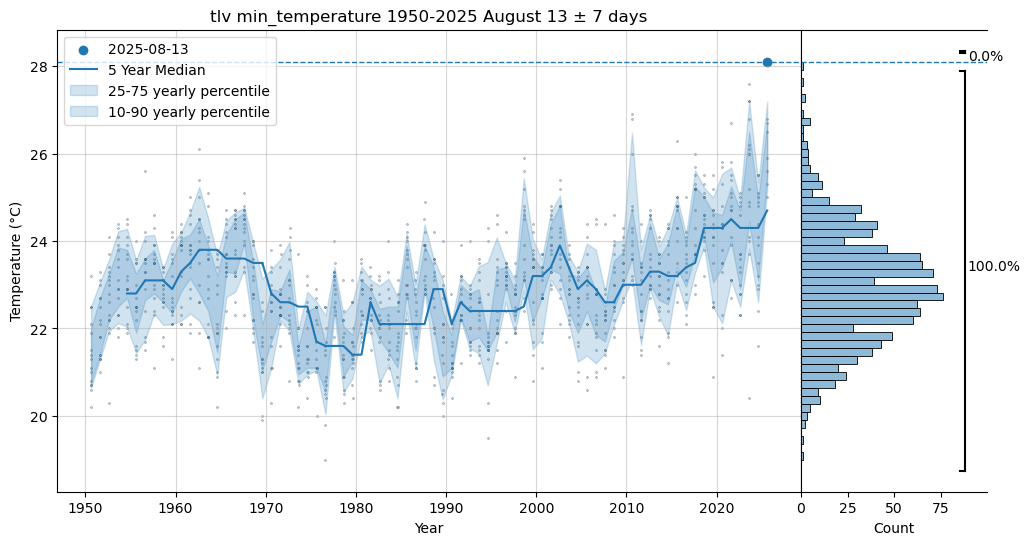

In [4]:
metric = 'min_temperature'

from plot_temperature_history import plot_temperature_history
fig, (ax_main, ax_hist) = plot_temperature_history(
    data=data[data['year'] > 1920],
    date=date,
    metric=metric,
    color='C0',
    title=f'{city} {metric} {data.year.min()}-2025 {month_name} {day_num} ± {days_range} days'
)


In [6]:
data.to_csv('example_data.csv', index=False)

Text(0.5, 1.0, 'Number of days above 33°C')

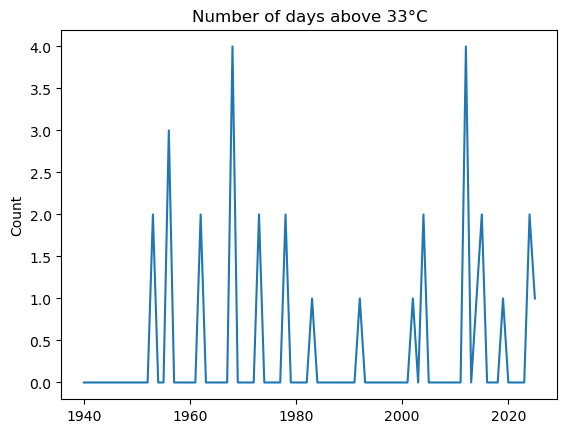

In [305]:
metric = 'max_temperature'
current_temp = 33 #data.loc[data['date'] == date, metric].values[0]
tmp_data = data.copy()
tmp_data['higher'] = tmp_data[metric] >= current_temp

plt.plot(tmp_data.groupby('year').higher.sum())
plt.ylabel('Count')
plt.title(f'Number of days above {current_temp}°C')


Text(0.5, 1.0, 'tlv max max_temperature 1940-2025 July 17 ± 7 days')

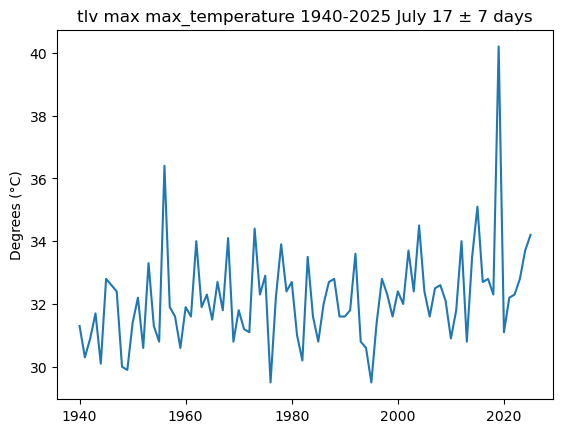

In [344]:
metric = 'max_temperature'

plt.plot(data.groupby('year')[metric].max())
plt.ylabel(f'Degrees (°C)')
plt.title(f'{city} max {metric} {data.year.min()}-2025 {month_name} {day_num} ± {days_range} days')

2025-07-17 is at the 0.6 percentile of max_temperature at 33.8 degrees


Text(0.5, 1.0, 'TLV max_temperature 1980-2025 July 17 +- 7 days (darker is older)')

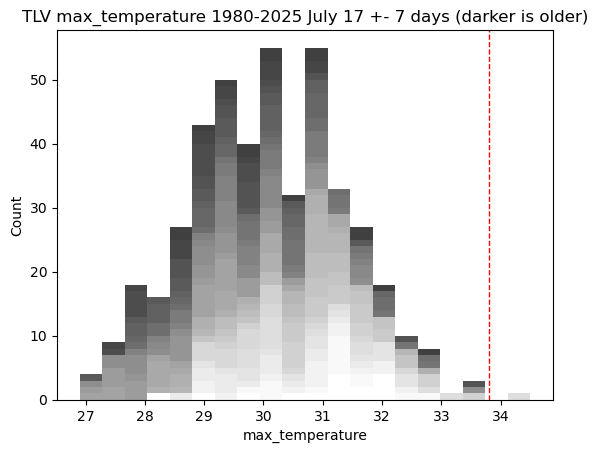

In [64]:
metric = 'max_temperature'
sns.histplot(data=data[data['year'] < 2010], stat="count", multiple="stack",
             x=metric, kde=False, edgecolor=None,
             palette="grey", hue="year", bins=20,
             element="bars", legend=False)
# Get the last date's max_temperature
current_temp = data.loc[data['date'] == date, metric].values[0]

# Draw a red vertical line at the last temperature value
plt.axvline(current_temp, color='red', linestyle='--', linewidth=1)

# Calculate the percentile: what percent of temperatures are higher than the last value
percent_higher = (data[metric] > current_temp).mean() * 100

print(f"{date} is at the {percent_higher:.1f} percentile of {metric} at {current_temp} degrees")

plt.title(f'TLV {metric} {data.year.min()}-2025 {month_name} {day_num} +- 7 days (darker is older)')


In [38]:
data.head()

,date,year,min_temperature,max_temperature,data_type
0,1980-07-10,1980,21.5,30.4,historical
1,1980-07-11,1980,21.8,31.5,historical
2,1980-07-12,1980,21.1,32.7,historical
3,1980-07-13,1980,21.7,31.9,historical
4,1980-07-14,1980,21.5,29.9,historical


<Axes: xlabel='year', ylabel='min_temperature'>

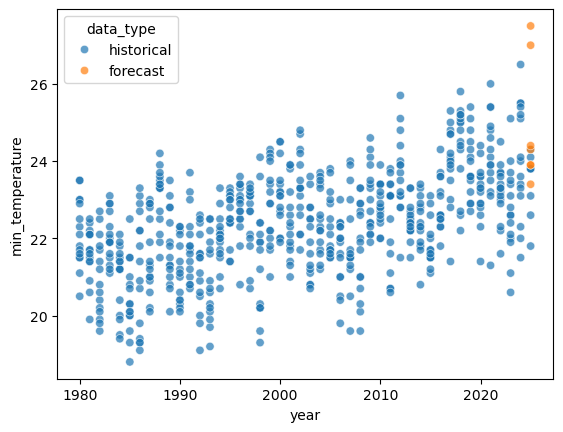

In [42]:
sns.scatterplot(data=data, x='year', y='min_temperature', hue='data_type', alpha=0.7)

2024-07-23 is at the 1.6 percentile of min_temperature at 25.2 degrees


Text(0.5, 1.0, 'TLV min_temperature daily temp 1980-2024 mid july (darker is older)')

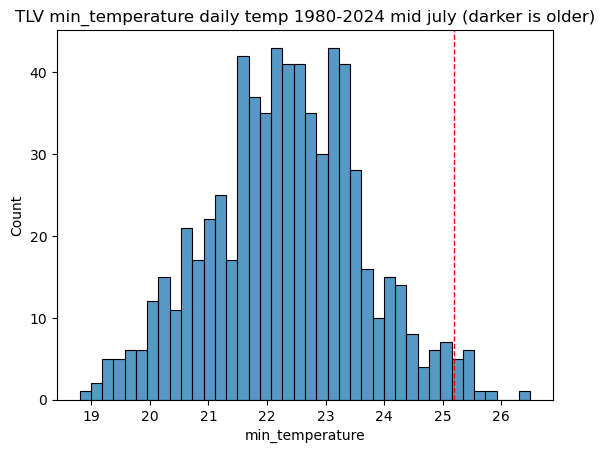

In [ ]:
metric = 'min_temperature'
sns.histplot(data=data, stat="count", multiple="stack",
             x=metric, kde=False, bins=40,
             element="bars", legend=False)
# Get the last date's max_temperature
last_row = data.sort_values("date").iloc[-1]
current_temp = last_row[metric]

# Draw a red vertical line at the last temperature value
plt.axvline(current_temp, color='red', linestyle='--', linewidth=1)

# Calculate the percentile: what percent of temperatures are higher than the last value
percent_higher = (data[metric] > current_temp).mean() * 100

print(f"{last_row['date']} is at the {percent_higher:.1f} percentile of {metric} at {current_temp} degrees")

plt.title(f'TLV {metric} daily temp 1980-2024 mid july (darker is older)')


<Axes: xlabel='year', ylabel='min_temperature'>

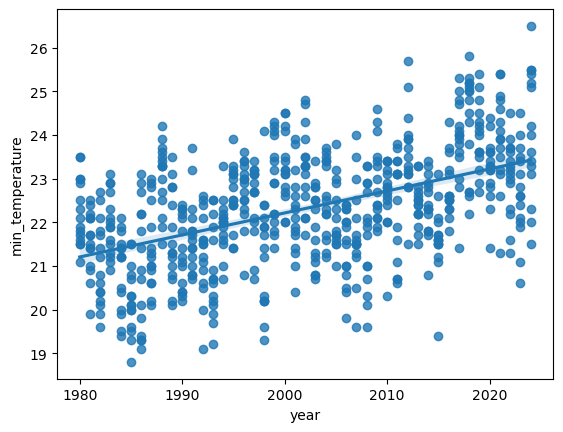

In [36]:
sns.regplot(data=test, y="min_temperature", x="year")